In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler


In [2]:
df = pd.read_csv("./data/cropdata_updated.csv")
print(f"Raw Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")
df.head(10)

Raw Dataset Shape: 16411 rows, 7 columns



,crop ID,soil_type,Seedling Stage,MOI,temp,humidity,result
0,Wheat,Black Soil,Germination,1,25,80.0,1
1,Wheat,Black Soil,Germination,2,26,77.0,1
2,Wheat,Black Soil,Germination,3,27,74.0,1
3,Wheat,Black Soil,Germination,4,28,71.0,1
4,Wheat,Black Soil,Germination,5,29,68.0,1
5,Wheat,Black Soil,Germination,6,30,65.0,1
6,Wheat,Black Soil,Germination,7,31,62.0,1
7,Wheat,Black Soil,Germination,8,32,59.0,1
8,Wheat,Black Soil,Germination,9,33,56.0,1
9,Wheat,Black Soil,Germination,10,34,53.0,1


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16411 entries, 0 to 16410
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   crop ID         16411 non-null  str    
 1   soil_type       16411 non-null  str    
 2   Seedling Stage  16411 non-null  str    
 3   MOI             16411 non-null  int64  
 4   temp            16411 non-null  int64  
 5   humidity        16411 non-null  float64
 6   result          16411 non-null  int64  
dtypes: float64(1), int64(3), str(3)
memory usage: 897.6 KB


In [4]:
df.drop_duplicates(inplace=True)
df.shape

(16283, 7)

In [5]:
df = df[df["result"] != 2]
df.shape

(15161, 7)

In [6]:
target_counts = df['result'].value_counts().sort_index()
target_pct = df['result'].value_counts(normalize=True).sort_index() * 100

target_summary = pd.DataFrame({
    'Count': target_counts,
    'Percentage (%)': target_pct.round(2),
    'Description': [
        '0: No Irrigation',
        '1: Standard Irrigation',
    ]
})
target_summary

,Count,Percentage (%),Description
result,,,
0,8934,58.93,0: No Irrigation
1,6227,41.07,1: Standard Irrigation


In [7]:
df.rename(columns={
    "crop ID": "crop_name",
    "soil_type": "soil_type",
    "Seedling Stage": "seedling_stage",
    "MOI": "moi",
    "temp": "temp",
    "humidity": "humidity",
    "result": "result",
}, inplace=True)
df.head()

,crop_name,soil_type,seedling_stage,moi,temp,humidity,result
0,Wheat,Black Soil,Germination,1,25,80.0,1
1,Wheat,Black Soil,Germination,2,26,77.0,1
2,Wheat,Black Soil,Germination,3,27,74.0,1
3,Wheat,Black Soil,Germination,4,28,71.0,1
4,Wheat,Black Soil,Germination,5,29,68.0,1


In [8]:
numerical_cols = ['moi', 'temp', 'humidity']

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    print(f"The column {col} has {len(outliers)} outliers that has a percentage of {round((len(outliers) / len(df)) * 100, 2)}%")



The column moi has 0 outliers that has a percentage of 0.0%
The column temp has 0 outliers that has a percentage of 0.0%
The column humidity has 0 outliers that has a percentage of 0.0%


In [9]:
GROWTH_STAGE_ORDER_MAP = {
    "Germination": 1,
    "Seedling Stage": 2,
    "Vegetative Growth / Root or Tuber Development": 3,
    "Flowering": 4,
    "Pollination": 5,
    "Fruit/Grain/Bulb Formation": 6,
    "Maturation": 7,
    "Harvest": 8,
}
df["growth_stage_order"] = (df["seedling_stage"].map(GROWTH_STAGE_ORDER_MAP).fillna(0).astype(int))

In [10]:
df["moi_temp_ratio"] = (df["moi"] / df["temp"].replace(0, np.nan)).round(4)
df["moi_humidity_index"] = ((df["moi"] * df["humidity"]) / 100.0).round(4)
df.shape

(15161, 10)

In [11]:
df.to_csv("./data/cleaned_data.csv", index=False)

In [12]:
numerical_cols = ["moi", "temp", "humidity", "growth_stage_order", "moi_temp_ratio", "moi_humidity_index"]
categorical_cols = ["crop_name", "soil_type"]
feature_cols = categorical_cols + numerical_cols
X = df[feature_cols]
y = df['result']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [13]:
processor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols)
    ],
    remainder="drop",
    verbose_feature_names_out=False
)


In [14]:
X_train_transformed = processor.fit_transform(X_train)
X_test_transformed = processor.transform(X_test)
feature_names = processor.get_feature_names_out()

X_train_transformed = pd.DataFrame(X_train_transformed, columns=feature_names, index=X_train.index)
X_test_transformed = pd.DataFrame(X_test_transformed, columns=feature_names, index=X_test.index)


## Machine Learning Models & Evaluation

We train and evaluate multiple classification models on the preprocessed dataset:
1. **Logistic Regression** (Linear baseline)
2. **K-Nearest Neighbors (KNN)** (Distance-based)
3. **Decision Tree** (Interpretable tree)
4. **Random Forest** (Bagging ensemble)
5. **XGBoost** (Gradient boosted trees)
6. **Support Vector Machine (SVM RBF)** (Kernel method)


In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, random_state=42, eval_metric="logloss"),
    "SVM (RBF)": SVC(probability=True, random_state=42)
}

results = []
trained_models = {}

for name, model in models.items():
    model.fit(X_train_transformed, y_train)
    trained_models[name] = model
    
    y_pred = model.predict(X_test_transformed)
    y_proba = model.predict_proba(X_test_transformed)[:, 1] if hasattr(model, "predict_proba") else None
    
    results.append({
        "Model": name,
        "Train Accuracy": round(model.score(X_train_transformed, y_train), 4),
        "Test Accuracy": round(accuracy_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred), 4),
        "Recall": round(recall_score(y_test, y_pred), 4),
        "F1-Score": round(f1_score(y_test, y_pred), 4),
        "ROC-AUC": round(roc_auc_score(y_test, y_proba) if y_proba is not None else 0.0, 4)
    })

results_df = pd.DataFrame(results).sort_values(by="F1-Score", ascending=False)
results_df


c:\Users\Dr\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1-Score,ROC-AUC
4,XGBoost,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
2,Decision Tree,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
3,Random Forest,1.0000,0.9993,0.9984,1.0000,0.9992,1.0000
5,SVM (RBF),0.9776,0.9805,0.9958,0.9567,0.9758,0.9985
1,KNN,0.9895,0.9703,0.9730,0.9543,0.9635,0.9964
0,Logistic Regression,0.9416,0.9426,0.9497,0.9085,0.9286,0.9858


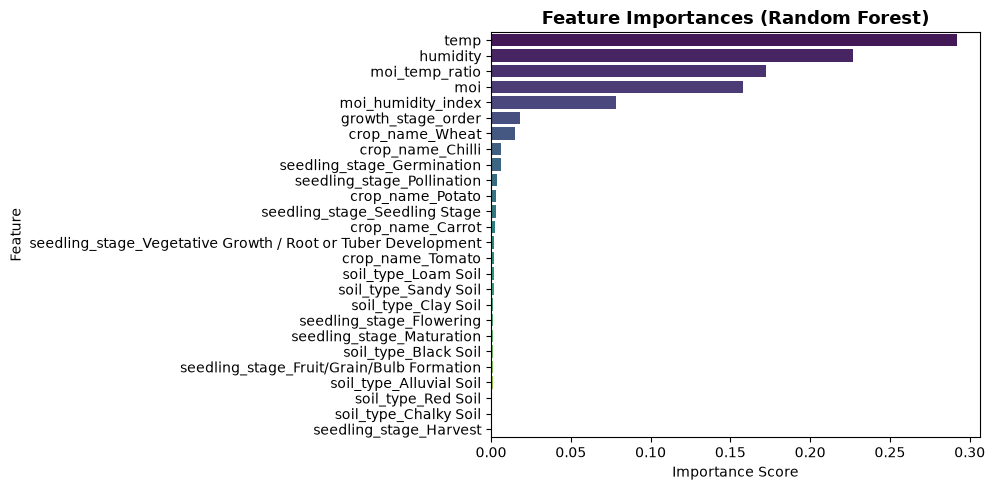

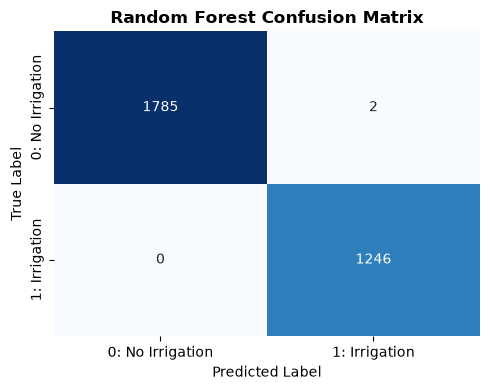

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
rf_model = trained_models["Random Forest"]
importances = pd.Series(rf_model.feature_importances_, index=feature_names).sort_values(ascending=False)
plt.figure(figsize=(10, 5))
sns.barplot(x=importances.values, y=importances.index, hue=importances.index, palette="viridis", legend=False)
plt.title("Feature Importances (Random Forest)", fontsize=13, weight="bold")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()
y_pred_rf = rf_model.predict(X_test_transformed)
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["0: No Irrigation", "1: Irrigation"],
            yticklabels=["0: No Irrigation", "1: Irrigation"])
plt.title("Random Forest Confusion Matrix", fontsize=12, weight="bold")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()
